<a href="https://colab.research.google.com/github/saniyaMulla12CODER/Ecombackend/blob/main/moviesp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import pandas as pd
uploaded=files.upload()
df=pd.read_csv("movies.csv")
print(df.head())
print(df.describe())

Saving movies.csv to movies.csv
   index     budget                                    genres  \
0      0  237000000  Action Adventure Fantasy Science Fiction   
1      1  300000000                  Adventure Fantasy Action   
2      2  245000000                    Action Adventure Crime   
3      3  250000000               Action Crime Drama Thriller   
4      4  260000000          Action Adventure Science Fiction   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   
3            http://www.thedarkknightrises.com/   49026   
4          http://movies.disney.com/john-carter   49529   

                                            keywords original_language  \
0  culture clash future space war space colony so...                en   
1  ocean drug abuse exotic island east india trad...                en   


In [ ]:
df=pd.read_csv("movies.csv")
display(df.head())

,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes
3,3,250000000,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,49026,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan
4,4,260000000,Action Adventure Science Fiction,http://movies.disney.com/john-carter,49529,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton


In [ ]:
print(df.isnull().sum())

index                      0
budget                     0
genres                    28
homepage                3091
id                         0
keywords                 412
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
cast                      43
crew                       0
director                  30
dtype: int64


### Data Preprocessing: Handling Missing Values

In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Fill missing values in text columns with an empty string
text_cols_to_fill = ['genres', 'homepage', 'keywords', 'overview', 'tagline', 'cast', 'director']
for col in text_cols_to_fill:
    if col in df.columns:
        df[col] = df[col].fillna('')

# For numerical columns with a few missing values, drop the rows
df.dropna(subset=['runtime', 'release_date'], inplace=True)

print("Missing values after initial handling:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values after initial handling:
Series([], dtype: int64)


### Label Encoding for Categorical Features

In [ ]:
# Initialize LabelEncoder
le = LabelEncoder()

if 'original_language' in df.columns:
    df['original_language_encoded'] = le.fit_transform(df['original_language'])
    print(f"'original_language' unique values before encoding: {df['original_language'].nunique()}")
    print(f"'original_language_encoded' unique values: {df['original_language_encoded'].nunique()}\n")

if 'status' in df.columns:
    df['status_encoded'] = le.fit_transform(df['status'])
    print(f"'status' unique values before encoding: {df['status'].nunique()}")
    print(f"'status_encoded' unique values: {df['status_encoded'].nunique()}\n")

display(df[['original_language', 'original_language_encoded', 'status', 'status_encoded']].head())

'original_language' unique values before encoding: 37
'original_language_encoded' unique values: 37

'status' unique values before encoding: 3
'status_encoded' unique values: 3



,original_language,original_language_encoded,status,status_encoded
0,en,7,Released,1
1,en,7,Released,1
2,en,7,Released,1
3,en,7,Released,1
4,en,7,Released,1


### Standard Scaling for Numerical Features

In [ ]:
# Select numerical columns for scaling
numerical_cols = ['budget', 'popularity', 'revenue', 'runtime', 'vote_average', 'vote_count']

# Initialize StandardScaler
scaler = StandardScaler()

# Apply Standard Scaling to the selected numerical columns
# Create new columns for scaled data to preserve original values
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("Scaled numerical features:")
display(df[numerical_cols].head())

Scaled numerical features:


,budget,popularity,revenue,runtime,vote_average,vote_count
0,5.105821,4.052064,16.611528,2.442541,0.930401,8.997440
1,6.652742,3.695201,5.394760,2.752835,0.677927,3.085186
2,5.302256,2.698753,4.901597,1.821953,0.172980,3.057650
3,5.425027,2.853887,6.155692,2.575524,1.267033,6.815575
4,5.670570,0.704659,1.239130,1.112709,0.004664,1.160869


### One-Hot Encoding for Categorical Features

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Columns to one-hot encode
ohe_cols = ['original_language', 'status']

# Initialize OneHotEncoder with sparse_output=False to get a dense array, and handle_unknown='ignore'
# handle_unknown='ignore' will set all one-hot encoded features to 0 for categories not seen during fit
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit and transform the selected columns
ohe_transformed = ohe.fit_transform(df[ohe_cols])

# Create a DataFrame with the one-hot encoded features
ohe_df = pd.DataFrame(ohe_transformed, columns=ohe.get_feature_names_out(ohe_cols), index=df.index)

# Concatenate the new one-hot encoded DataFrame with the original DataFrame
df = pd.concat([df, ohe_df], axis=1)

# Drop the original categorical columns and their label-encoded versions to avoid multicollinearity and redundancy
df.drop(columns=ohe_cols + ['original_language_encoded', 'status_encoded'], inplace=True)

print("DataFrame head after one-hot encoding:")
display(df.head())
print(f"New DataFrame shape: {df.shape}")

DataFrame head after one-hot encoding:


,index,budget,genres,homepage,id,keywords,original_title,overview,popularity,production_companies,...,original_language_ta,original_language_te,original_language_th,original_language_tr,original_language_vi,original_language_xx,original_language_zh,status_Post Production,status_Released,status_Rumored
0,0,5.105821,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,Avatar,"In the 22nd century, a paraplegic Marine is di...",4.052064,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1,6.652742,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",3.695201,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,2,5.302256,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,Spectre,A cryptic message from Bond’s past sends him o...,2.698753,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,3,5.425027,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,49026,dc comics crime fighter terrorist secret ident...,The Dark Knight Rises,Following the death of District Attorney Harve...,2.853887,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,4,5.670570,Action Adventure Science Fiction,http://movies.disney.com/john-carter,49529,based on novel mars medallion space travel pri...,John Carter,"John Carter is a war-weary, former military ca...",0.704659,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


New DataFrame shape: (4800, 62)


Now that we've added one-hot encoded features, you might want to update the `features` list in the `Train-Test Split` cell (`0d67fba9`) to include these new columns and re-run the split. For example, you would replace `'original_language_encoded'` and `'status_encoded'` with the newly created one-hot encoded columns (e.g., `'original_language_en'`, `'status_Released'`, etc.).

In [ ]:
display(df.head())

,index,budget,genres,homepage,id,keywords,original_title,overview,popularity,production_companies,...,original_language_ta,original_language_te,original_language_th,original_language_tr,original_language_vi,original_language_xx,original_language_zh,status_Post Production,status_Released,status_Rumored
0,0,5.105821,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,Avatar,"In the 22nd century, a paraplegic Marine is di...",4.052064,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1,6.652742,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",3.695201,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,2,5.302256,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,Spectre,A cryptic message from Bond’s past sends him o...,2.698753,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,3,5.425027,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,49026,dc comics crime fighter terrorist secret ident...,The Dark Knight Rises,Following the death of District Attorney Harve...,2.853887,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,4,5.670570,Action Adventure Science Fiction,http://movies.disney.com/john-carter,49529,based on novel mars medallion space travel pri...,John Carter,"John Carter is a war-weary, former military ca...",0.704659,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### Prepare Target for Logistic Regression

In [ ]:
# Create a binary target variable for logistic regression
# Let's define 'high_revenue' as movies with revenue above the median
median_revenue = df['revenue'].median()
df['high_revenue'] = (df['revenue'] > median_revenue).astype(int)

print(f"Median Revenue: {median_revenue}")
print("Distribution of 'high_revenue':")
display(df['high_revenue'].value_counts())

Median Revenue: -0.38759099325915847
Distribution of 'high_revenue':


,count
high_revenue,
1,2400
0,2400


### Update Train-Test Split with One-Hot Encoded Features

### Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Initialize the Logistic Regression model
log_reg = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets and binary classification

# Train the model
log_reg.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Model Evaluation

### Support Vector Machine (SVM) Model

In [ ]:
from sklearn.svm import SVC

# Initialize the SVM model
# Using 'rbf' kernel as it often performs well for non-linear decision boundaries
# probability=True is needed to compute ROC AUC score, but can slow down training
svm_model = SVC(random_state=42, probability=True)

# Train the model
svm_model.fit(X_train, y_train)

print("SVM model trained successfully.")

SVM model trained successfully.


### SVM Model Evaluation

In [ ]:
# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test)
y_pred_proba_svm = svm_model.predict_proba(X_test)[:, 1] # Probability of the positive class

# Evaluate the model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
roc_auc_svm = roc_auc_score(y_test, y_pred_proba_svm)
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)

print(f"SVM Accuracy: {accuracy_svm:.4f}")
print(f"SVM Precision: {precision_svm:.4f}")
print(f"SVM Recall: {recall_svm:.4f}")
print(f"SVM F1-Score: {f1_svm:.4f}")
print(f"SVM ROC AUC Score: {roc_auc_svm:.4f}")
print("\nSVM Confusion Matrix:")
print(conf_matrix_svm)

SVM Accuracy: 0.8594
SVM Precision: 0.8647
SVM Recall: 0.8521
SVM F1-Score: 0.8583
SVM ROC AUC Score: 0.9329

SVM Confusion Matrix:
[[416  64]
 [ 71 409]]


### Random Forest Classifier Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest model
# Using default parameters for now, but these can be tuned
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### Random Forest Model Evaluation

In [ ]:
# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1] # Probability of the positive class

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Precision: {precision_rf:.4f}")
print(f"Random Forest Recall: {recall_rf:.4f}")
print(f"Random Forest F1-Score: {f1_rf:.4f}")
print(f"Random Forest ROC AUC Score: {roc_auc_rf:.4f}")
print("\nRandom Forest Confusion Matrix:")
print(conf_matrix_rf)

Random Forest Accuracy: 0.8615
Random Forest Precision: 0.8684
Random Forest Recall: 0.8521
Random Forest F1-Score: 0.8601
Random Forest ROC AUC Score: 0.9316

Random Forest Confusion Matrix:
[[418  62]
 [ 71 409]]


### K-Nearest Neighbors (KNN) Model

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNN model
# Using default n_neighbors=5, but this can be tuned
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train, y_train)

print("KNN model trained successfully.")

KNN model trained successfully.


### KNN Model Evaluation

In [ ]:
# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test)
y_pred_proba_knn = knn_model.predict_proba(X_test)[:, 1] # Probability of the positive class

# Evaluate the model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
roc_auc_knn = roc_auc_score(y_test, y_pred_proba_knn)
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)

print(f"KNN Accuracy: {accuracy_knn:.4f}")
print(f"KNN Precision: {precision_knn:.4f}")
print(f"KNN Recall: {recall_knn:.4f}")
print(f"KNN F1-Score: {f1_knn:.4f}")
print(f"KNN ROC AUC Score: {roc_auc_knn:.4f}")
print("\nKNN Confusion Matrix:")
print(conf_matrix_knn)

KNN Accuracy: 0.8292
KNN Precision: 0.8405
KNN Recall: 0.8125
KNN F1-Score: 0.8263
KNN ROC AUC Score: 0.9007

KNN Confusion Matrix:
[[406  74]
 [ 90 390]]


In [ ]:
# Make predictions on the test set
y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1] # Probability of the positive class

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)

# Optional: Display feature coefficients to understand importance
# coefficients = pd.DataFrame({'feature': X.columns, 'coefficient': log_reg.coef_[0]})
# coefficients = coefficients.sort_values(by='coefficient', ascending=False)
# print("\nFeature Coefficients:")
# display(coefficients.head(10))

Accuracy: 0.8479
Precision: 0.8830
Recall: 0.8021
F1-Score: 0.8406
ROC AUC Score: 0.9292

Confusion Matrix:
[[429  51]
 [ 95 385]]


### Data Visualization: Distributions of Features

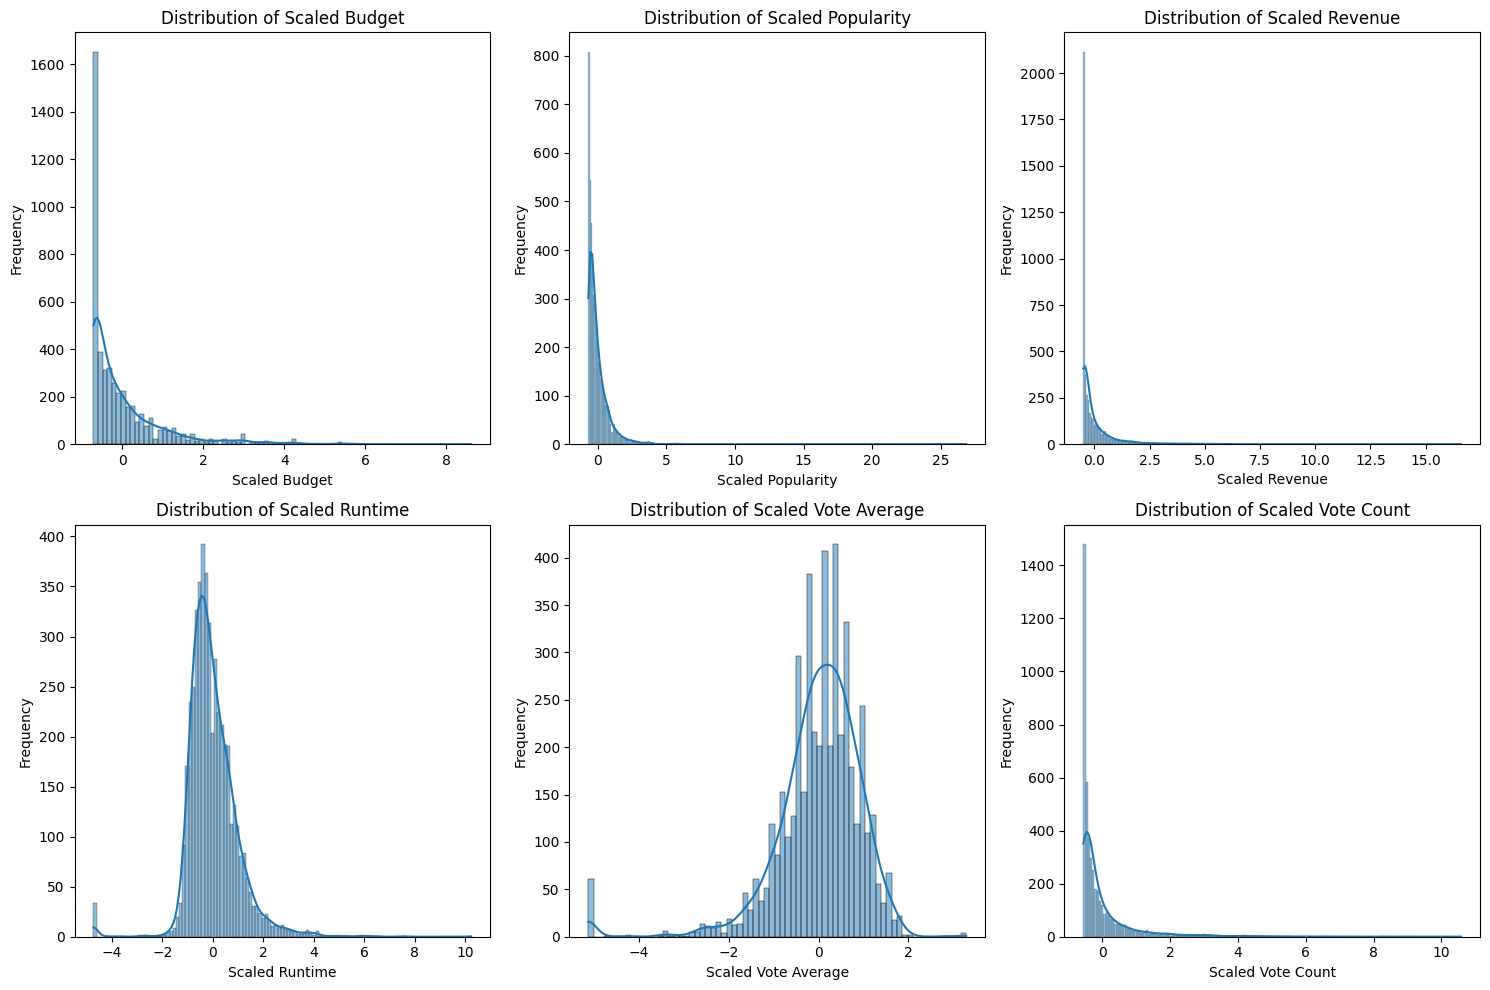

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograms for scaled numerical features
numerical_cols = ['budget', 'popularity', 'revenue', 'runtime', 'vote_average', 'vote_count']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Arrange plots in 2 rows, 3 columns
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of Scaled {col.replace("_", " ").title()}')
    plt.xlabel(f'Scaled {col.replace("_", " ").title()}')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1768/1886539686.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='status', data=df, palette='viridis')


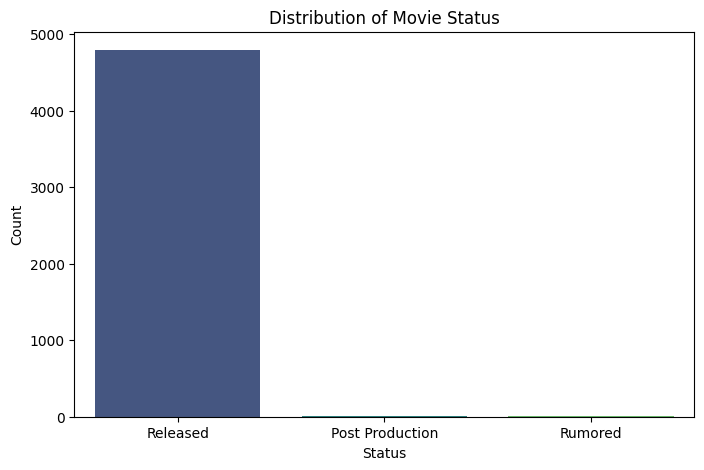

In [ ]:
# Bar plot for 'status'
plt.figure(figsize=(8, 5))
sns.countplot(x='status', data=df, palette='viridis')
plt.title('Distribution of Movie Status')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_1768/2426981192.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='original_language', data=df[df['original_language'].isin(top_languages)], order=top_languages, palette='magma')


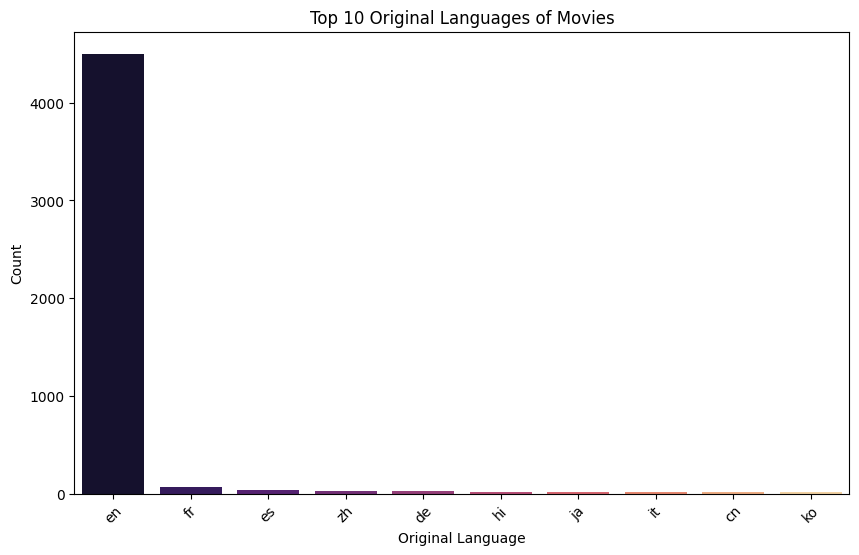

In [ ]:
# Bar plot for top 10 'original_language'
top_languages = df['original_language'].value_counts().head(10).index
plt.figure(figsize=(10, 6))
sns.countplot(x='original_language', data=df[df['original_language'].isin(top_languages)], order=top_languages, palette='magma')
plt.title('Top 10 Original Languages of Movies')
plt.xlabel('Original Language')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### Boxplot of 'vote_average' by 'high_revenue'

In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder

# --- Data Loading ---
# This will prompt you to upload 'movies.csv' if it's not already in the session.
# If it is already uploaded, you can cancel the prompt, or upload it again.
uploaded = files.upload()
df = pd.read_csv("movies.csv")

# --- Data Preprocessing: Handling Missing Values ---
text_cols_to_fill = ['genres', 'homepage', 'keywords', 'overview', 'tagline', 'cast', 'director']
for col in text_cols_to_fill:
    if col in df.columns:
        df[col] = df[col].fillna('')

df.dropna(subset=['runtime', 'release_date'], inplace=True)

# --- Label Encoding for Categorical Features (Intermediate step before OHE) ---
le = LabelEncoder()

if 'original_language' in df.columns:
    df['original_language_encoded'] = le.fit_transform(df['original_language'])

if 'status' in df.columns:
    df['status_encoded'] = le.fit_transform(df['status'])

# --- Standard Scaling for Numerical Features ---
numerical_cols = ['budget', 'popularity', 'revenue', 'runtime', 'vote_average', 'vote_count']
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# --- One-Hot Encoding for Categorical Features ---
ohe_cols = ['original_language', 'status']
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_transformed = ohe.fit_transform(df[ohe_cols])
ohe_df = pd.DataFrame(ohe_transformed, columns=ohe.get_feature_names_out(ohe_cols), index=df.index)
df = pd.concat([df, ohe_df], axis=1)
df.drop(columns=ohe_cols + ['original_language_encoded', 'status_encoded'], inplace=True)

# --- Prepare Target for Logistic Regression ---
median_revenue = df['revenue'].median()
df['high_revenue'] = (df['revenue'] > median_revenue).astype(int)

print("DataFrame 'df' and 'high_revenue' column are now prepared.")


Saving movies.csv to movies.csv
DataFrame 'df' and 'high_revenue' column are now prepared.


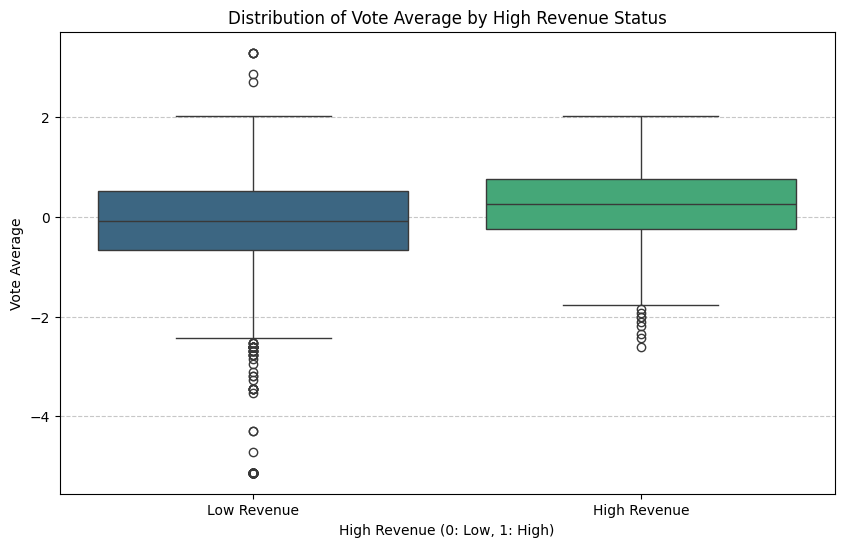

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='high_revenue', y='vote_average', data=df, hue='high_revenue', palette='viridis', legend=False)
plt.title('Distribution of Vote Average by High Revenue Status')
plt.xlabel('High Revenue (0: Low, 1: High)')
plt.ylabel('Vote Average')
plt.xticks([0, 1], ['Low Revenue', 'High Revenue'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Correlation Heatmap of Numerical Features

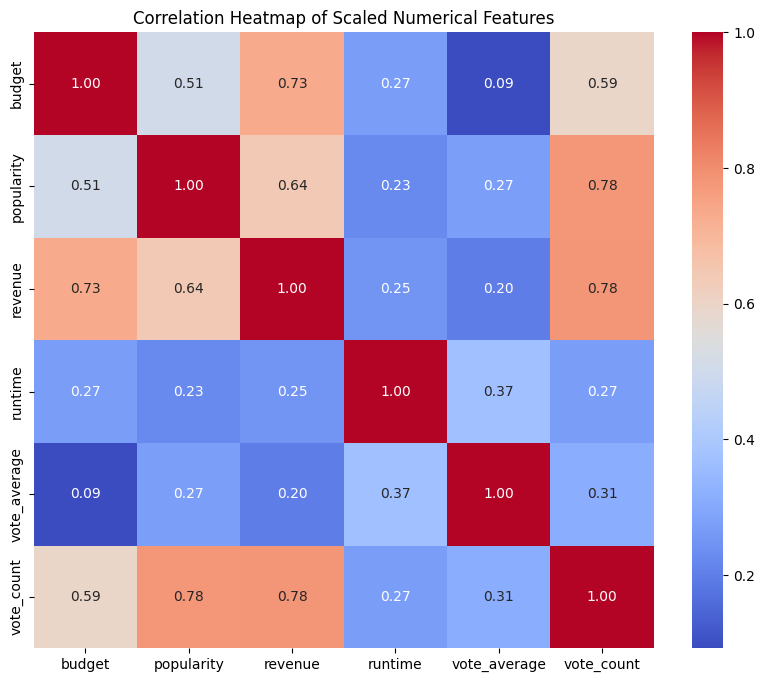

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Scaled Numerical Features')
plt.show()

### Pie Chart of Movie Status Distribution

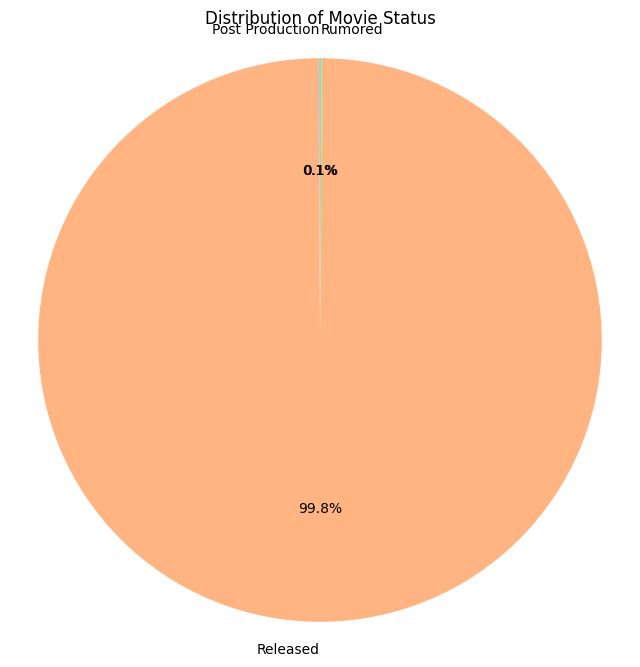

In [ ]:
status_ohe_cols = [col for col in df.columns if col.startswith('status_')]
status_counts = df[status_ohe_cols].sum()

# Rename the index to remove 'status_' prefix for better labels
status_counts.index = status_counts.index.str.replace('status_', '')

plt.figure(figsize=(8, 8))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribution of Movie Status')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# Collect all one-hot encoded columns dynamically
one_hot_cols = [col for col in df.columns if col.startswith('original_language_') or col.startswith('status_')]

# Using scaled numerical features and one-hot encoded categorical features
features = ['budget', 'popularity', 'runtime', 'vote_average', 'vote_count'] + one_hot_cols

X = df[features]
y = df['high_revenue'] # Use the newly created binary target variable

# Perform the train-test split (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
print("\nDistribution of 'high_revenue' in y_train:")
display(y_train.value_counts(normalize=True))
print("\nDistribution of 'high_revenue' in y_test:")
display(y_test.value_counts(normalize=True))

Shape of X_train: (3840, 45)
Shape of X_test: (960, 45)
Shape of y_train: (3840,)
Shape of y_test: (960,)

Distribution of 'high_revenue' in y_train:


,proportion
high_revenue,
0,0.5
1,0.5



Distribution of 'high_revenue' in y_test:


,proportion
high_revenue,
0,0.5
1,0.5
